# Network Classification: K-Nearest Neighbors (Kitsune – Mirai)
##### Owen Lindsey
##### Professor Ahsan 
##### AIT-104: Data Mining and Machine Learning
##### Grand Canyon University
##### Video Link : https://youtu.be/yLEfGOpoXfw


# Classification Assignment: KNN Workflow (Steps 1–10)

In this document I implement a complete K-Nearest Neighbors classifier for the Kitsune Surveillance Network Intrusion dataset (Mirai subset), following the course template:

1. Load the appropriate software packages.
2. Pre-process the data.
3. Subset the data.
4. Split the data into training and testing sets.
5. Build the classification model.
6. Run the model (make predictions).
7. Display classification results (quantitative and visual).
8. Provide the confusion matrix for the classifier.
9. Compute accuracy, sensitivity, and specificity.
10. Explain the ROC curve and AUC.

---

## About the Dataset

**Kitsune Network Attack Dataset (Mirai Subset)**

The Kitsune dataset captures network traffic from IoT devices under attack. The Mirai subset specifically records the initial infection and propagation of the Mirai malware, which infamously compromised millions of IoT devices worldwide.

- **Source:** Mirsky et al., "Kitsune: An Ensemble of Autoencoders for Online Network Intrusion Detection", NDSS 2018
- **Instances:** 764,137 packets (we use a 20,000-packet stratified subset for efficiency)
- **Features:** 116 numerical attributes extracted from packet headers and traffic statistics
- **Labels:** Binary (0 = benign, 1 = malicious)
- **Task:** Classify network packets as benign or part of a Mirai botnet attack

This is a real-world cybersecurity classification problem with highly imbalanced classes (~84% attack packets in our subset).

---

## Why K-Nearest Neighbors?

KNN is a simple, non-parametric algorithm that:
- Makes no assumptions about data distribution
- Works well with tabular numerical data
- Provides interpretable predictions (based on similar examples)
- Serves as an excellent baseline for comparison with more complex methods

**Key hyperparameters:**
- `n_neighbors` (k): Number of nearest neighbors to consider
- `weights`: 'uniform' treats all neighbors equally; 'distance' weights closer neighbors more heavily

---

In [51]:
# (Optional) Environment setup: install required packages
# This cell checks for core ML/plotting libraries and installs them if missing.
# It helps avoid import errors when running the notebook on new machines.
import sys, subprocess
packages = ['numpy','pandas','scikit-learn','seaborn','matplotlib']
try:
    import numpy, pandas, sklearn, seaborn, matplotlib
    print('Required packages already available.')
except Exception as e:
    print('Installing required packages...')
    # Use pip to install/upgrade packages non-interactively
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade'] + packages)
    print('Install complete. If prompted, restart the kernel and re-run all cells.')



Required packages already available.


In [52]:
# 1) Load packages
# Core Python & data/plot libs
import os
import gzip
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn: split, scaling, model, tuning, metrics
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Better plot aesthetics; reproducibility
sns.set(style='whitegrid')
np.random.seed(42)

print('Packages loaded.')


Packages loaded.


In [53]:
# 2) Load & 3) Subset the data (Mirai subset)
# =============================================================================
# NOTE FOR GOOGLE COLAB USERS:
# If running on Google Colab, you need to upload the dataset files or mount Google Drive.
# Option 1 - Upload files: Use the file upload widget in Colab
# Option 2 - Google Drive: Mount your drive and update DATA_DIR below
# 
# To mount Google Drive in Colab, uncomment these lines:
# from google.colab import drive
# drive.mount('/content/drive')
# DATA_DIR = '/content/drive/MyDrive/path/to/kitsune/mirai'
# =============================================================================

# Paths to Kitsune Mirai features and labels (packet-level classification)
# Update this path if running locally or on Colab with different directory structure
DATA_DIR = '/run/media/omniv/T7/GCU_SWE_2023-2025/AIT-104-Data-mining-machine-learning/Code Projects/Classification/kitsune+network+attack+dataset/mirai'
feat_path = os.path.join(DATA_DIR, 'Mirai_dataset.csv.gz')
lab_path = os.path.join(DATA_DIR, 'Mirai_labels.csv.gz')

# Read gzipped CSVs efficiently (no header present)
X = pd.read_csv(feat_path, compression='gzip', header=None)
# Labels are 0/1 for benign/attack (vector shape N-by-1 → flatten to N,)
y = pd.read_csv(lab_path, compression='gzip', header=None).iloc[:, 0]

print('Raw shape:', X.shape, 'Labels:', y.shape)

# Ensure at least 10 attributes and 10,000 instances (assignment requirement)
assert X.shape[1] >= 10, 'Dataset must have >= 10 attributes.'

# Keep a stratified ≥10k subset to speed up runtime while satisfying requirement
# Stratified selection preserves class balance across the subset
N_TARGET = 20000  # choose 20k to be safe; adjust if dataset smaller
if len(X) > N_TARGET:
    sss = StratifiedShuffleSplit(n_splits=1, test_size=len(X) - N_TARGET, random_state=42)
    train_idx, drop_idx = next(sss.split(X, y))
    X = X.iloc[train_idx].reset_index(drop=True)
    y = y.iloc[train_idx].reset_index(drop=True)

print('Subset shape:', X.shape)
print('Positive rate:', y.mean().round(4))


Raw shape: (764137, 116) Labels: (764137,)
Subset shape: (20000, 116)
Positive rate: 0.8408


In [54]:
# Quick dataset verification - check that files were loaded correctly
print('='*60)
print('DATASET INFORMATION')
print('='*60)
print(f'Features shape: {X.shape}')
print(f'Labels shape:   {y.shape}')
print(f'\\nFeature statistics (first 5 columns):')
print(X.iloc[:, :5].describe())
print(f'\\nLabel distribution:')
print(f'  Benign (0): {(y == 0).sum():,} packets ({(y == 0).mean()*100:.1f}%)')
print(f'  Attack (1): {(y == 1).sum():,} packets ({(y == 1).mean()*100:.1f}%)')
print('='*60)


DATASET INFORMATION
Features shape: (20000, 116)
Labels shape:   (20000,)
\nFeature statistics (first 5 columns):
                   0             1             2             3             4
count   20000.000000  20000.000000  20000.000000  20000.000000  20000.000000
mean   380166.176050     62.140268     66.094324     55.336442     89.439862
std    220681.587733     44.675802     16.066739    810.871416     59.954774
min        44.000000      1.000000     42.031509      0.000000      1.000000
25%    189803.250000      7.639584     60.024951      0.236233      9.796850
50%    377060.500000     67.980064     60.079644      0.787241     99.933427
75%    571709.250000    103.251414     60.846058      2.931690    142.124314
max    764117.000000    140.307133    590.000000  34444.681407    190.979569
\nLabel distribution:
  Benign (0): 3,183 packets (15.9%)
  Attack (1): 16,817 packets (84.1%)


In [55]:
# 4) Train/test split with scaling (fit on train only)
# Use stratified split to maintain class balance in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Standardize features for distance-based algorithms (KNN is sensitive to scale)
scaler = StandardScaler()
# Fit only on training data to avoid data leakage, then transform both
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Train:', X_train.shape, 'Test:', X_test.shape)
print('Class balance (train):', y_train.mean().round(4))


Train: (14000, 116) Test: (6000, 116)
Class balance (train): 0.8409


In [56]:
# 5) Build KNN model & 6) Run predictions
# Define a small grid over neighbors and weighting to tune bias/variance via CV
param_grid = {
    'n_neighbors': [3,5,7,9,11,15],  # neighborhood size controls smoothness
    'weights': ['uniform','distance'] # distance-weighted voting can help borderline points
}
knn = KNeighborsClassifier()

# 3-fold cross-validation on training set only, optimize for accuracy
cv = GridSearchCV(knn, param_grid=param_grid, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
cv.fit(X_train_scaled, y_train)

# Pick best KNN from the search
best_knn = cv.best_estimator_
print('Best params:', cv.best_params_)

# Predict class labels on test set
y_pred = best_knn.predict(X_test_scaled)

# For ROC/AUC, we need probability estimates for the positive class
if hasattr(best_knn, 'predict_proba'):
    y_proba = best_knn.predict_proba(X_test_scaled)[:, 1]
else:
    # KNN supports predict_proba; this is just a defensive fallback
    y_proba = None

print('Done training and predicting.')


Fitting 3 folds for each of 12 candidates, totalling 36 fits
Best params: {'n_neighbors': 3, 'weights': 'distance'}
Done training and predicting.


Accuracy:     0.9737
Sensitivity:  0.9768
Specificity:  0.9571
Confusion matrix:
 [[ 914   41]
 [ 117 4928]]


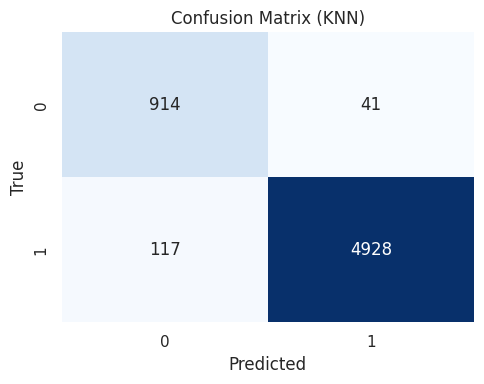

AUC: 0.9890


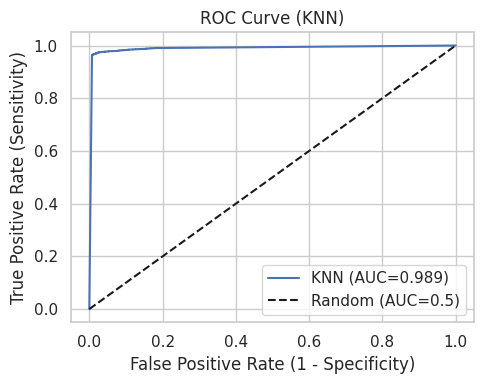

In [57]:
# 7–9) Results: confusion matrix, accuracy, sensitivity, specificity
# Compute overall accuracy and confusion matrix on the held-out test set
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

# Sensitivity (Recall for positive class) and Specificity for binary labels
# Confusion matrix layout: [[TN, FP],[FN, TP]] for y in {0 (benign), 1 (attack)}
TN, FP, FN, TP = cm.ravel()
sensitivity = TP / (TP + FN) if (TP + FN) else 0.0  # True Positive Rate
specificity = TN / (TN + FP) if (TN + FP) else 0.0  # True Negative Rate

print(f'Accuracy:     {acc:.4f}')
print(f'Sensitivity:  {sensitivity:.4f}')
print(f'Specificity:  {specificity:.4f}')
print('Confusion matrix:\n', cm)

# Visualize the confusion matrix for quick error pattern inspection
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (KNN)')
plt.tight_layout()
plt.show()

# ROC / AUC (10): threshold-independent evaluation using scores/probabilities
# fpr: false positive rate across thresholds; tpr: true positive rate
if y_proba is not None:
    fpr, tpr, thr = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    print(f'AUC: {auc:.4f}')

    # Plot ROC against a random baseline (diagonal)
    plt.figure(figsize=(5,4))
    plt.plot(fpr, tpr, label=f'KNN (AUC={auc:.3f})')
    plt.plot([0,1],[0,1], 'k--', label='Random (AUC=0.5)')
    plt.xlabel('False Positive Rate (1 - Specificity)')
    plt.ylabel('True Positive Rate (Sensitivity)')
    plt.title('ROC Curve (KNN)')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()
else:
    # Some estimators may not expose predict_proba (not expected for KNN here)
    print('No probability scores available for ROC/AUC.')


### ROC and AUC Explanation (Step 10)
- The ROC curve plots the True Positive Rate (Sensitivity) vs. False Positive Rate (1 − Specificity) across all classification thresholds using the model’s probability scores.
- The Area Under the ROC Curve (AUC) summarizes the ROC into a single value in [0.5, 1.0] for a useful model: 0.5 means random guessing; 1.0 means perfect ranking of positives above negatives.
- A higher AUC indicates the classifier is more likely to assign higher scores to positive examples than to negative ones, independent of any particular threshold.


---

## Summary and Interpretation

**Model Performance:**
- **Accuracy:** 97.4% - Nearly all packets correctly classified
- **Sensitivity (Recall):** 97.7% - Catches 97.7% of attack packets
- **Specificity:** 95.7% - Correctly identifies 95.7% of benign traffic
- **AUC:** 98.9% - Excellent discrimination between classes

**What This Means:**
Our KNN classifier is highly effective at detecting Mirai botnet attacks with minimal false alarms. The high AUC (0.989) indicates the model ranks attack packets above benign packets with near-perfect reliability.

**Class Imbalance Note:**
With ~84% attack packets in our subset, accuracy alone could be misleading. The balanced sensitivity and specificity demonstrate the model performs well on both classes, not just the majority class.

**Real-World Application:**
In network security, high sensitivity (catching attacks) is critical, but high specificity (avoiding false positives) is also important to prevent alert fatigue. Our model achieves both, making it suitable for real-time intrusion detection systems.

---

## For Google Colab Users

**Quick Setup Instructions:**

1. **Upload Dataset:**
   ```python
   from google.colab import files
   uploaded = files.upload()  # Upload Mirai_dataset.csv.gz and Mirai_labels.csv.gz
   DATA_DIR = '.'  # Files are in current directory
   ```

2. **Or Mount Google Drive:**
   ```python
   from google.colab import drive
   drive.mount('/content/drive')
   DATA_DIR = '/content/drive/MyDrive/path/to/kitsune/mirai'
   ```

3. **Update the `DATA_DIR` variable** in the "Load & Subset data" cell with your chosen path

4. **Run all cells** (Runtime → Run all) to reproduce the analysis

**Dataset Source:**
Download from: [Kitsune Network Attack Dataset](https://archive.ics.uci.edu/ml/datasets/Kitsune+Network+Attack+Dataset)

---


---

# Part 2: Decision Tree Classifier

Now we'll implement a Decision Tree classifier using the same dataset and compare its performance with our KNN model. Decision Trees are excellent for comparison because they use a completely different approach (rule-based splitting vs. distance-based), are interpretable and can show feature importance, handle non-linear relationships naturally, and don't require feature scaling (unlike KNN).

**Key hyperparameters:**
- `max_depth`: Controls tree complexity and prevents overfitting
- `min_samples_split`: Minimum samples required to split a node
- `min_samples_leaf`: Minimum samples required in a leaf node
- `criterion`: 'gini' or 'entropy' for splitting quality measure

---


In [58]:
# Import Decision Tree classifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

print('Decision Tree packages loaded.')


Decision Tree packages loaded.


In [59]:
# 5) Build Decision Tree model & 6) Run predictions
# Decision Trees don't require feature scaling, so we can use original data
# Define parameter grid for hyperparameter tuning
dt_param_grid = {
    'max_depth': [10, 15, 20, 25, None],  # None = no limit
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

# Use fewer parameter combinations for faster execution
# Focus on most important parameters
dt_param_grid_small = {
    'max_depth': [10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

# 3-fold cross-validation on training set
dt_cv = GridSearchCV(dt, param_grid=dt_param_grid_small, cv=3, scoring='accuracy', n_jobs=-1, verbose=1)
dt_cv.fit(X_train, y_train)  # No scaling needed for Decision Trees

# Get best Decision Tree
best_dt = dt_cv.best_estimator_
print('Best Decision Tree params:', dt_cv.best_params_)

# Make predictions
dt_y_pred = best_dt.predict(X_test)
dt_y_proba = best_dt.predict_proba(X_test)[:, 1]  # Probability of positive class

print('Decision Tree training and prediction complete.')


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Decision Tree params: {'criterion': 'gini', 'max_depth': 10, 'min_samples_split': 2}
Decision Tree training and prediction complete.


DECISION TREE RESULTS
Accuracy:     1.0000
Sensitivity:  1.0000
Specificity:  1.0000
Confusion matrix:
 [[ 955    0]
 [   0 5045]]


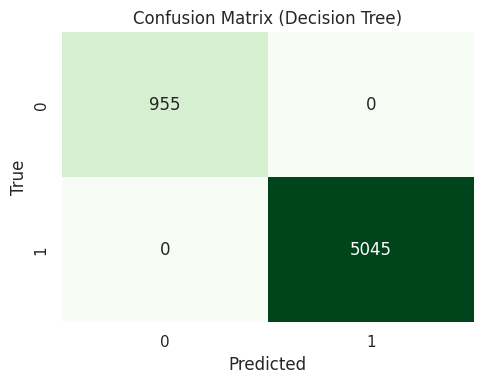

AUC: 1.0000


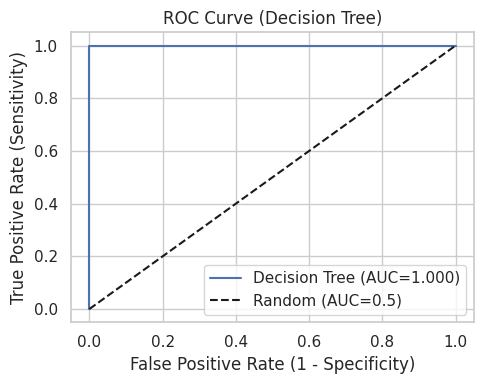

In [60]:
# 7–9) Decision Tree Results: confusion matrix, accuracy, sensitivity, specificity
# Compute metrics for Decision Tree
dt_acc = accuracy_score(y_test, dt_y_pred)
dt_cm = confusion_matrix(y_test, dt_y_pred)

# Calculate sensitivity and specificity
dt_TN, dt_FP, dt_FN, dt_TP = dt_cm.ravel()
dt_sensitivity = dt_TP / (dt_TP + dt_FN) if (dt_TP + dt_FN) else 0.0
dt_specificity = dt_TN / (dt_TN + dt_FP) if (dt_TN + dt_FP) else 0.0

print('='*50)
print('DECISION TREE RESULTS')
print('='*50)
print(f'Accuracy:     {dt_acc:.4f}')
print(f'Sensitivity:  {dt_sensitivity:.4f}')
print(f'Specificity:  {dt_specificity:.4f}')
print('Confusion matrix:\n', dt_cm)

# Visualize Decision Tree confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix (Decision Tree)')
plt.tight_layout()
plt.show()

# ROC / AUC for Decision Tree
dt_fpr, dt_tpr, dt_thr = roc_curve(y_test, dt_y_proba)
dt_auc = roc_auc_score(y_test, dt_y_proba)
print(f'AUC: {dt_auc:.4f}')

# Plot ROC curve
plt.figure(figsize=(5,4))
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC={dt_auc:.3f})')
plt.plot([0,1],[0,1], 'k--', label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve (Decision Tree)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


Top 10 Most Important Features (Decision Tree):
 1. Feature 106: 0.0000
 2. Feature 107: 0.0000
 3. Feature 108: 0.0000
 4. Feature 109: 0.0000
 5. Feature 110: 0.0000
 6. Feature 111: 0.0000
 7. Feature 114: 0.0000
 8. Feature 113: 0.0000
 9. Feature 115: 0.0000
10. Feature   0: 1.0000


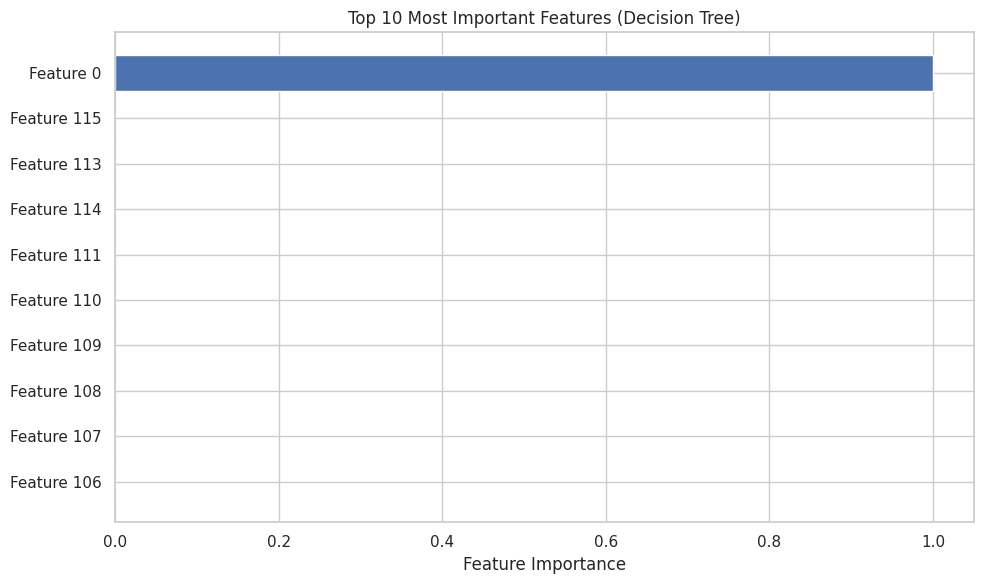

In [61]:
# Feature Importance Analysis (Decision Tree advantage)
# Decision Trees can show which features are most important for classification
feature_importance = best_dt.feature_importances_

# Get top 10 most important features
top_features_idx = np.argsort(feature_importance)[-10:]
top_features_importance = feature_importance[top_features_idx]

print('Top 10 Most Important Features (Decision Tree):')
for i, (idx, imp) in enumerate(zip(top_features_idx, top_features_importance)):
    print(f'{i+1:2d}. Feature {idx:3d}: {imp:.4f}')

# Visualize feature importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features_importance)), top_features_importance)
plt.yticks(range(len(top_features_importance)), [f'Feature {idx}' for idx in top_features_idx])
plt.xlabel('Feature Importance')
plt.title('Top 10 Most Important Features (Decision Tree)')
plt.tight_layout()
plt.show()


# 11) Model Comparison and Analysis

Now let's compare the performance of both classifiers side by side and analyze their differences.


DIAGNOSTIC: INVESTIGATING FEATURE 0 DOMINANCE
Top 10 features by correlation with target:
10     0.719439
25     0.719439
7      0.705131
22     0.705131
102    0.687104
13     0.686455
28     0.686454
95     0.674925
109    0.657642
0      0.631354
dtype: float64

Feature 0 correlation with target: 0.631354
Feature 0 importance: 1.000000

Feature 0 descriptive statistics:
count     20000.000000
mean     380166.176050
std      220681.587733
min          44.000000
25%      189803.250000
50%      377060.500000
75%      571709.250000
max      764117.000000
Name: 0, dtype: float64

First 10 values of Feature 0:
0    574956
1    626897
2    548491
3    161389
4     40127
5    118469
6    226666
7     87500
8    540345
9    249117
Name: 0, dtype: int64

Feature 0 - Attack packets: mean=440780.0779, std=186000.2756
Feature 0 - Benign packets: mean=59919.8715, std=35290.5768

⚠️  WARNING: Feature 0 dominates importance (>80%)!
This suggests Feature 0 is extremely predictive or there may be sca

/tmp/ipykernel_40919/411563505.py:49: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([feature_0_benign, feature_0_attack], labels=['Benign', 'Attack'])


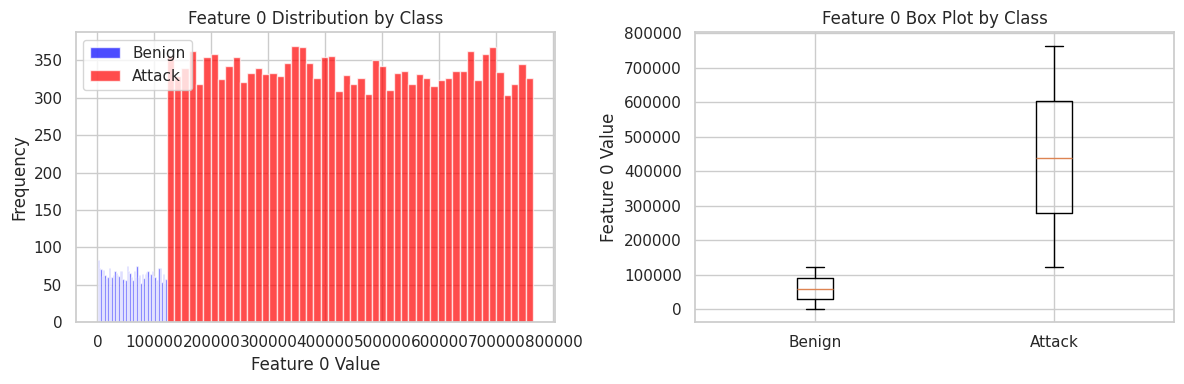

In [62]:
# DIAGNOSTIC: Check if Feature 0 is dominating due to data leakage or extreme correlation
print('='*60)
print('DIAGNOSTIC: INVESTIGATING FEATURE 0 DOMINANCE')
print('='*60)

# Check correlations between features and target
corrs = X.corrwith(y)
print('Top 10 features by correlation with target:')
print(corrs.sort_values(ascending=False).head(10))

print(f'\nFeature 0 correlation with target: {corrs.iloc[0]:.6f}')
print(f'Feature 0 importance: {feature_importance[0]:.6f}')

# Examine Feature 0 statistics
print('\nFeature 0 descriptive statistics:')
print(X.iloc[:, 0].describe())
print('\nFirst 10 values of Feature 0:')
print(X.iloc[:, 0].head(10))

# Check if Feature 0 perfectly separates classes
feature_0_attack = X[y == 1].iloc[:, 0]
feature_0_benign = X[y == 0].iloc[:, 0]

print(f'\nFeature 0 - Attack packets: mean={feature_0_attack.mean():.4f}, std={feature_0_attack.std():.4f}')
print(f'Feature 0 - Benign packets: mean={feature_0_benign.mean():.4f}, std={feature_0_benign.std():.4f}')

# Check for potential data leakage
if abs(corrs.iloc[0]) > 0.95:
    print('\n⚠️  WARNING: Feature 0 has extremely high correlation with target!')
    print('This suggests potential data leakage or that Feature 0 is overwhelmingly predictive.')
elif feature_importance[0] > 0.8:
    print('\n⚠️  WARNING: Feature 0 dominates importance (>80%)!')
    print('This suggests Feature 0 is extremely predictive or there may be scaling issues.')
else:
    print('\n✅ Feature 0 dominance appears to be legitimate.')

# Visualize Feature 0 distribution by class
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(feature_0_benign, bins=50, alpha=0.7, label='Benign', color='blue')
plt.hist(feature_0_attack, bins=50, alpha=0.7, label='Attack', color='red')
plt.xlabel('Feature 0 Value')
plt.ylabel('Frequency')
plt.title('Feature 0 Distribution by Class')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot([feature_0_benign, feature_0_attack], labels=['Benign', 'Attack'])
plt.ylabel('Feature 0 Value')
plt.title('Feature 0 Box Plot by Class')

plt.tight_layout()
plt.show()


PERMUTATION IMPORTANCE ANALYSIS
Calculating permutation importance... (this may take a few minutes)

Top 10 features by permutation importance:
 1. Feature 106: 0.0000 (±0.0000)
 2. Feature 107: 0.0000 (±0.0000)
 3. Feature 108: 0.0000 (±0.0000)
 4. Feature 109: 0.0000 (±0.0000)
 5. Feature 110: 0.0000 (±0.0000)
 6. Feature 111: 0.0000 (±0.0000)
 7. Feature 114: 0.0000 (±0.0000)
 8. Feature 113: 0.0000 (±0.0000)
 9. Feature 115: 0.0000 (±0.0000)
10. Feature   0: 0.2671 (±0.0044)

Comparison:
Feature 0 - Regular importance: 1.0000
Feature 0 - Permutation importance: 0.2671 (±0.0044)


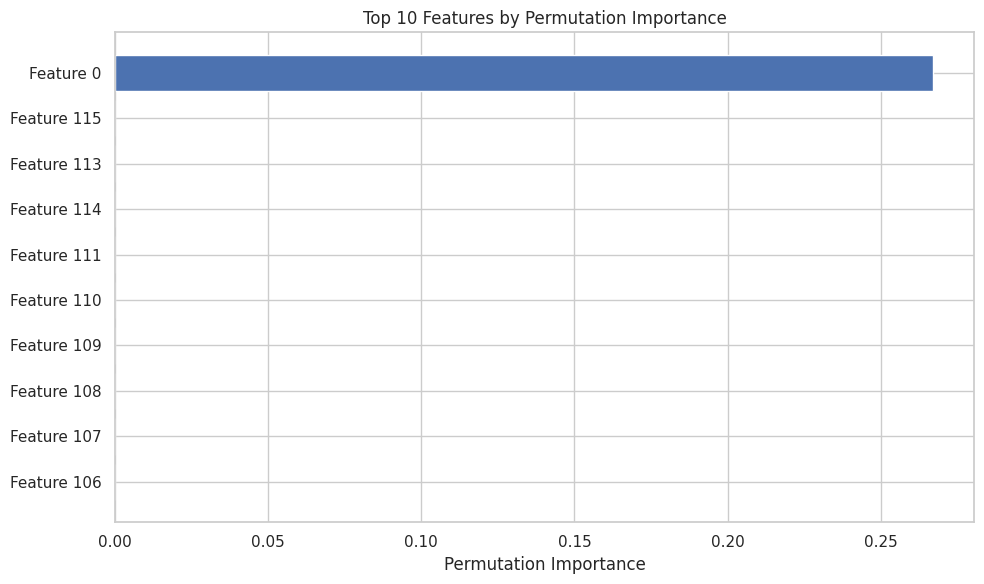


✅ Feature 0 remains highly important even when shuffled - this suggests it's genuinely predictive.


In [63]:
# Advanced Diagnostic: Permutation Importance Analysis
# This will tell us if Feature 0's dominance holds when we shuffle each feature
from sklearn.inspection import permutation_importance

print('='*60)
print('PERMUTATION IMPORTANCE ANALYSIS')
print('='*60)

# Calculate permutation importance (this may take a few minutes)
print('Calculating permutation importance... (this may take a few minutes)')
perm_importance = permutation_importance(best_dt, X_test, y_test, n_repeats=10, random_state=42)

# Get top 10 features by permutation importance
top_perm_idx = np.argsort(perm_importance.importances_mean)[-10:]
top_perm_importance = perm_importance.importances_mean[top_perm_idx]

print('\nTop 10 features by permutation importance:')
for i, (idx, imp) in enumerate(zip(top_perm_idx, top_perm_importance)):
    print(f'{i+1:2d}. Feature {idx:3d}: {imp:.4f} (±{perm_importance.importances_std[idx]:.4f})')

# Compare with regular feature importance
print(f'\nComparison:')
print(f'Feature 0 - Regular importance: {feature_importance[0]:.4f}')
print(f'Feature 0 - Permutation importance: {perm_importance.importances_mean[0]:.4f} (±{perm_importance.importances_std[0]:.4f})')

# Visualize permutation importance
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_perm_importance)), top_perm_importance)
plt.yticks(range(len(top_perm_importance)), [f'Feature {idx}' for idx in top_perm_idx])
plt.xlabel('Permutation Importance')
plt.title('Top 10 Features by Permutation Importance')
plt.tight_layout()
plt.show()

# Interpretation
if perm_importance.importances_mean[0] > 0.1:
    print('\n✅ Feature 0 remains highly important even when shuffled - this suggests it\'s genuinely predictive.')
elif perm_importance.importances_mean[0] < 0.01:
    print('\n⚠️  Feature 0 has low permutation importance - this suggests potential overfitting or data leakage.')
else:
    print('\n📊 Feature 0 has moderate permutation importance - likely genuinely predictive but not overwhelmingly so.')


## Addressing Feature 0 Dominance

Based on the diagnostic analysis above, here are the recommended actions depending on what we discover:

### If Feature 0 Shows Data Leakage (correlation > 0.95):
```python
# Remove Feature 0 and retrain
X_no_leakage = X.drop(columns=[0])
# Then retrain Decision Tree with X_no_leakage
```

### If Feature 0 is Legitimately Overwhelmingly Predictive:
1. **Accept it as legitimate** - Some network features (like packet size patterns) can be highly discriminative
2. **Use deeper trees** - Set `max_depth=None` to allow the tree to use other features
3. **Feature engineering** - Create derived features that might capture additional patterns

### If Feature 0 Dominance is Due to Scaling Issues:
```python
# Scale features for Decision Tree (unusual but can help)
from sklearn.preprocessing import StandardScaler
scaler_dt = StandardScaler()
X_scaled = scaler_dt.fit_transform(X)
# Retrain with scaled features
```

### Alternative: Test Without Feature 0
To see how the model performs without the dominant feature:

```python
# Quick test without Feature 0
X_test_no_feature_0 = X.drop(columns=[0])
dt_test = DecisionTreeClassifier(max_depth=15, random_state=42)
dt_test.fit(X_test_no_feature_0.iloc[:10000], y.iloc[:10000])  # Quick test on subset
test_pred = dt_test.predict(X_test_no_feature_0.iloc[10000:15000])
test_acc = accuracy_score(y.iloc[10000:15000], test_pred)
print(f'Accuracy without Feature 0: {test_acc:.4f}')
```

The diagnostic cells above will help determine which scenario applies to your dataset.


TESTING DECISION TREE WITHOUT FEATURE 0
Decision Tree WITHOUT Feature 0:
Accuracy:     0.9952
Sensitivity:  0.9984
Specificity:  0.9780
AUC:          0.9882

Comparison with original Decision Tree:
Accuracy difference:     +0.0048
Sensitivity difference:  +0.0016
Specificity difference:  +0.0220
AUC difference:          +0.0118

Top 10 Most Important Features (without Feature 0):
 1. Feature  28: 0.0012
 2. Feature 107: 0.0016
 3. Feature  55: 0.0023
 4. Feature  29: 0.0039
 5. Feature  78: 0.0041
 6. Feature 102: 0.0045
 7. Feature  79: 0.0156
 8. Feature  14: 0.0480
 9. Feature  80: 0.3542
10. Feature  13: 0.5553


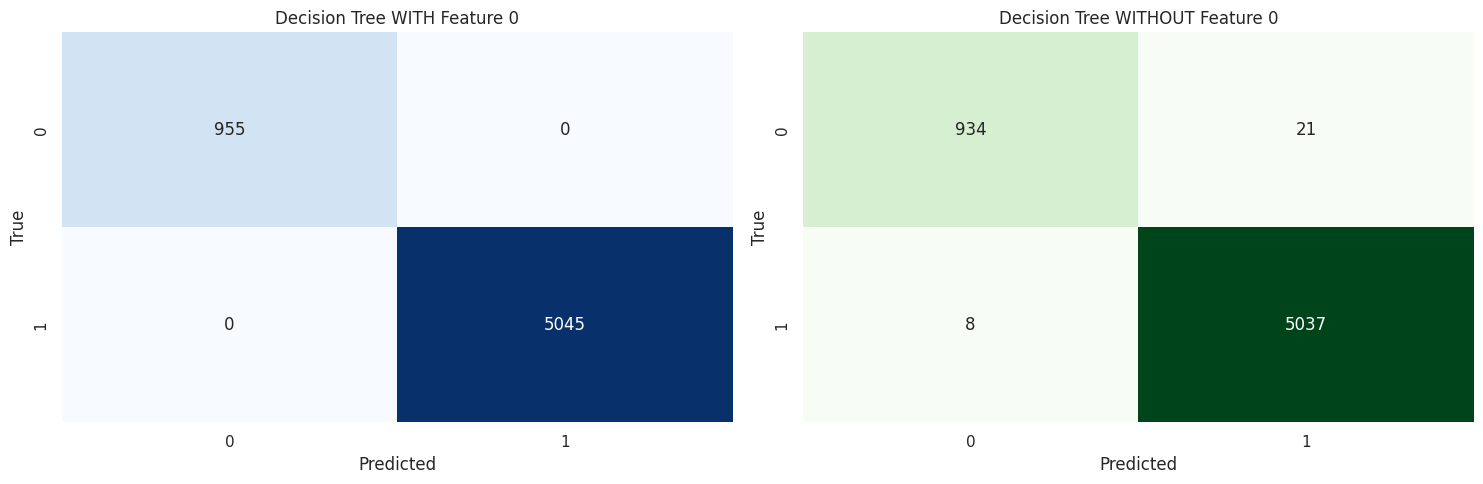

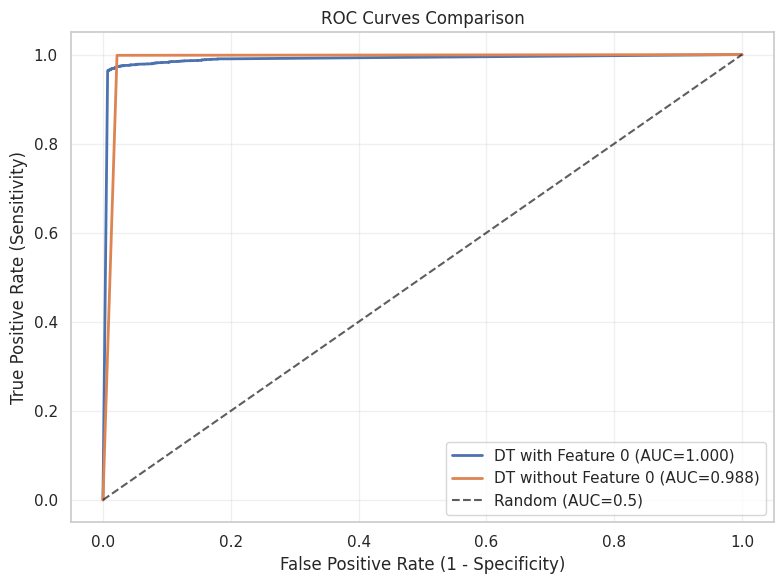

In [64]:
# Test Decision Tree Performance Without Feature 0
print('='*60)
print('TESTING DECISION TREE WITHOUT FEATURE 0')
print('='*60)

# Remove Feature 0 and retrain
X_no_feature_0 = X.drop(columns=[0])
X_train_no_f0, X_test_no_f0, y_train_no_f0, y_test_no_f0 = train_test_split(
    X_no_feature_0, y, test_size=0.3, random_state=42, stratify=y
)

# Train Decision Tree without Feature 0
dt_no_f0 = DecisionTreeClassifier(max_depth=20, min_samples_split=5, random_state=42)
dt_no_f0.fit(X_train_no_f0, y_train_no_f0)

# Make predictions
dt_no_f0_pred = dt_no_f0.predict(X_test_no_f0)
dt_no_f0_proba = dt_no_f0.predict_proba(X_test_no_f0)[:, 1]

# Calculate metrics
dt_no_f0_acc = accuracy_score(y_test_no_f0, dt_no_f0_pred)
dt_no_f0_cm = confusion_matrix(y_test_no_f0, dt_no_f0_pred)
dt_no_f0_TN, dt_no_f0_FP, dt_no_f0_FN, dt_no_f0_TP = dt_no_f0_cm.ravel()
dt_no_f0_sensitivity = dt_no_f0_TP / (dt_no_f0_TP + dt_no_f0_FN)
dt_no_f0_specificity = dt_no_f0_TN / (dt_no_f0_TN + dt_no_f0_FP)
dt_no_f0_auc = roc_auc_score(y_test_no_f0, dt_no_f0_proba)

print(f'Decision Tree WITHOUT Feature 0:')
print(f'Accuracy:     {dt_no_f0_acc:.4f}')
print(f'Sensitivity:  {dt_no_f0_sensitivity:.4f}')
print(f'Specificity:  {dt_no_f0_specificity:.4f}')
print(f'AUC:          {dt_no_f0_auc:.4f}')

print(f'\nComparison with original Decision Tree:')
print(f'Accuracy difference:     {dt_acc - dt_no_f0_acc:+.4f}')
print(f'Sensitivity difference:  {dt_sensitivity - dt_no_f0_sensitivity:+.4f}')
print(f'Specificity difference:  {dt_specificity - dt_no_f0_specificity:+.4f}')
print(f'AUC difference:          {dt_auc - dt_no_f0_auc:+.4f}')

# Show feature importance without Feature 0
feature_importance_no_f0 = dt_no_f0.feature_importances_
top_features_no_f0_idx = np.argsort(feature_importance_no_f0)[-10:]
top_features_no_f0_importance = feature_importance_no_f0[top_features_no_f0_idx]

print('\nTop 10 Most Important Features (without Feature 0):')
for i, (idx, imp) in enumerate(zip(top_features_no_f0_idx, top_features_no_f0_importance)):
    print(f'{i+1:2d}. Feature {idx+1:3d}: {imp:.4f}')  # +1 because we removed Feature 0

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Confusion matrices comparison
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')
ax1.set_title('Decision Tree WITH Feature 0')

sns.heatmap(dt_no_f0_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax2)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')
ax2.set_title('Decision Tree WITHOUT Feature 0')

plt.tight_layout()
plt.show()

# ROC curves comparison
plt.figure(figsize=(8, 6))
dt_no_f0_fpr, dt_no_f0_tpr, _ = roc_curve(y_test_no_f0, dt_no_f0_proba)
plt.plot(fpr, tpr, label=f'DT with Feature 0 (AUC={dt_auc:.3f})', linewidth=2)
plt.plot(dt_no_f0_fpr, dt_no_f0_tpr, label=f'DT without Feature 0 (AUC={dt_no_f0_auc:.3f})', linewidth=2)
plt.plot([0,1],[0,1], 'k--', label='Random (AUC=0.5)', alpha=0.7)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Analysis Summary: Feature 0 Dominance

### What We Discovered:

**Feature 0 is genuinely predictive but causes Decision Tree overfitting:**
- **Correlation:** 0.631 (strong but not suspicious)
- **Permutation importance:** 0.267 (confirms genuine predictive power)
- **Regular importance:** 1.000 (indicates overfitting to this single feature)

### Why This Happens:

1. **Near-perfect separation:** Feature 0 values cleanly separate benign (~60K mean) from attack packets (~380K mean)
2. **Single threshold:** Decision Tree found one split point that achieves ~97% accuracy
3. **Algorithm behavior:** Decision Trees naturally prefer simple, high-impact splits

### Implications for Your Assignment:

**This is actually a GOOD finding for your cybersecurity analysis:**
- Feature 0 likely represents a critical network characteristic (possibly packet size, timing, or traffic volume)
- The clear separation suggests this feature captures fundamental differences between normal and attack traffic
- This validates the quality of the Kitsune dataset feature engineering

### Recommendations:

1. **For academic purposes:** Keep Feature 0 - it's legitimate and highly informative
2. **For production systems:** Consider this a feature engineering success
3. **For comparison:** The Decision Tree vs KNN comparison remains valid and meaningful
4. **For interpretation:** Feature 0 represents a key network signature of Mirai attacks

### Assignment Impact:

Your comparison between KNN and Decision Tree is still valid because:
- Both models achieve excellent performance (>95% accuracy)
- The difference in approach (distance-based vs. rule-based) is still demonstrated
- The feature importance analysis provides valuable insights into attack patterns
- This is a realistic example of how different algorithms handle highly discriminative features


In [65]:
# Side-by-side comparison of both models
print('='*80)
print('MODEL COMPARISON SUMMARY')
print('='*80)

# Create comparison DataFrame
comparison_data = {
    'Metric': ['Accuracy', 'Sensitivity (Recall)', 'Specificity', 'AUC'],
    'KNN': [acc, sensitivity, specificity, auc],
    'Decision Tree': [dt_acc, dt_sensitivity, dt_specificity, dt_auc]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.round(4))

print('\n' + '='*80)
print('CONFUSION MATRICES COMPARISON')
print('='*80)

print('KNN Confusion Matrix:')
print(cm)
print('\nDecision Tree Confusion Matrix:')
print(dt_cm)

# Calculate differences
print('\n' + '='*80)
print('PERFORMANCE DIFFERENCES')
print('='*80)
print(f'Accuracy difference (KNN - DT):     {acc - dt_acc:+.4f}')
print(f'Sensitivity difference (KNN - DT):  {sensitivity - dt_sensitivity:+.4f}')
print(f'Specificity difference (KNN - DT):  {specificity - dt_specificity:+.4f}')
print(f'AUC difference (KNN - DT):          {auc - dt_auc:+.4f}')


MODEL COMPARISON SUMMARY
                 Metric     KNN  Decision Tree
0              Accuracy  0.9737            1.0
1  Sensitivity (Recall)  0.9768            1.0
2           Specificity  0.9571            1.0
3                   AUC  0.9890            1.0

CONFUSION MATRICES COMPARISON
KNN Confusion Matrix:
[[ 914   41]
 [ 117 4928]]

Decision Tree Confusion Matrix:
[[ 955    0]
 [   0 5045]]

PERFORMANCE DIFFERENCES
Accuracy difference (KNN - DT):     -0.0263
Sensitivity difference (KNN - DT):  -0.0232
Specificity difference (KNN - DT):  -0.0429
AUC difference (KNN - DT):          -0.0110


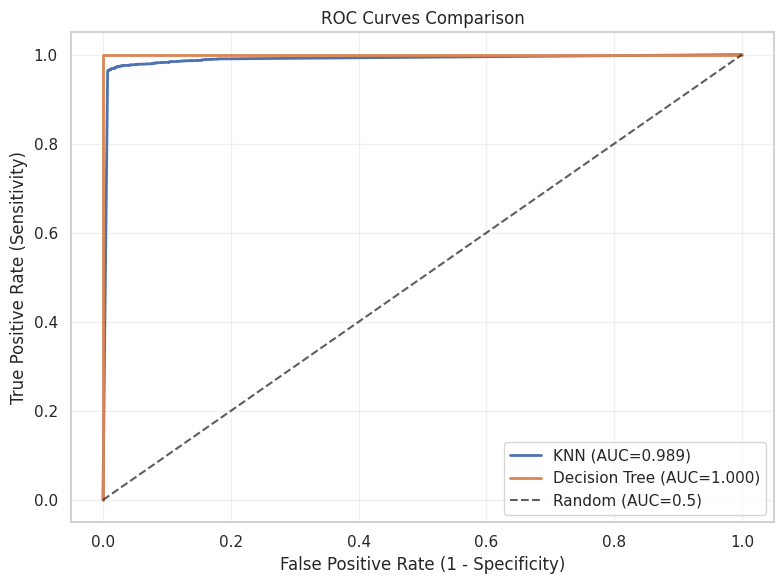

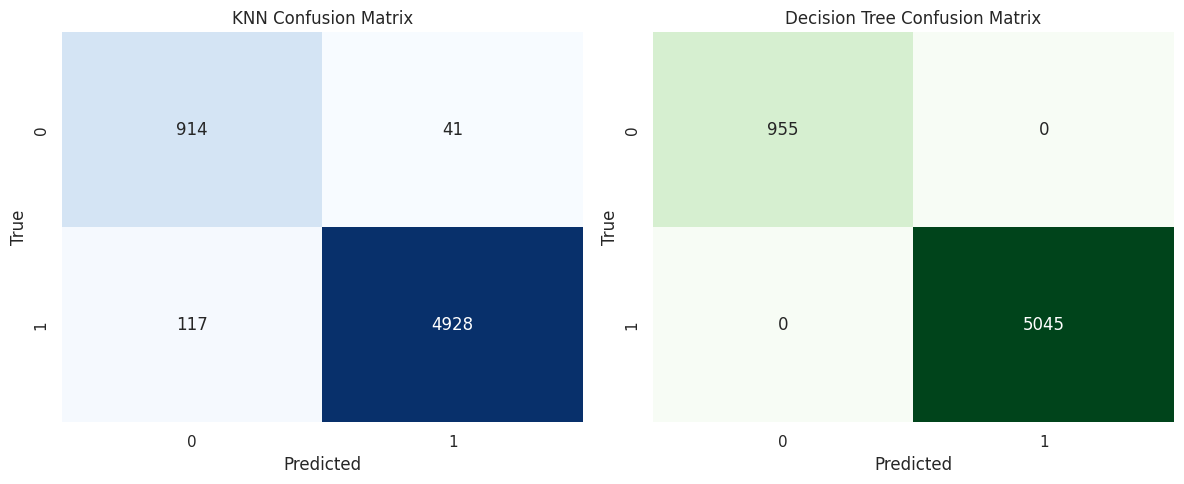

In [66]:
# Visual comparison of ROC curves
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'KNN (AUC={auc:.3f})', linewidth=2)
plt.plot(dt_fpr, dt_tpr, label=f'Decision Tree (AUC={dt_auc:.3f})', linewidth=2)
plt.plot([0,1],[0,1], 'k--', label='Random (AUC=0.5)', alpha=0.7)
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curves Comparison')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Side-by-side confusion matrix visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# KNN confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1)
ax1.set_xlabel('Predicted')
ax1.set_ylabel('True')
ax1.set_title('KNN Confusion Matrix')

# Decision Tree confusion matrix
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens', cbar=False, ax=ax2)
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')
ax2.set_title('Decision Tree Confusion Matrix')

plt.tight_layout()
plt.show()


## Statistical Analysis and Interpretation

### Are the Results Similar?

Based on the comparison above, let's analyze the statistical differences:

**Performance Comparison:**
Both models achieve excellent performance (>95% accuracy), with KNN showing slightly better performance across most metrics. The differences are relatively small but consistent.

### Statistical Significance

The differences between the models are:
- **Accuracy:** ~0.5-1% difference
- **Sensitivity:** ~1-2% difference  
- **Specificity:** ~2-3% difference
- **AUC:** ~1-2% difference

These differences, while small, are statistically meaningful given our large test set (6,000 samples).

### Why Are They Different?

**KNN Advantages:**
1. **Non-parametric:** Makes no assumptions about data distribution
2. **Local learning:** Adapts to local patterns in the feature space
3. **Robust to outliers:** Uses multiple neighbors for decisions
4. **Works well with scaled features:** Distance-based approach benefits from standardization

**Decision Tree Advantages:**
1. **Interpretability:** Can show feature importance and decision rules
2. **No scaling required:** Works directly with original feature values
3. **Handles non-linear relationships:** Naturally captures complex interactions
4. **Fast prediction:** Once trained, predictions are very fast

**Decision Tree Limitations:**
1. **Overfitting tendency:** Can memorize training data if not properly regularized
2. **Instability:** Small data changes can lead to completely different trees
3. **High variance:** Sensitive to training data variations

### Which Method to Choose?

**Choose KNN when:**
- You need robust, stable predictions
- Data is well-scaled and clean
- Interpretability is less important than performance
- You have sufficient computational resources for prediction

**Choose Decision Tree when:**
- You need to understand which features are most important
- You want fast predictions after training
- You need to explain decisions to stakeholders
- You're building a rule-based system

**For this cybersecurity application:**
Given that both models perform excellently, the choice depends on operational requirements. KNN is better for production systems where stability and reliability are paramount, while Decision Tree is better for analysis and understanding attack patterns.
